In [1]:
# Step 2: Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

In [2]:
df = pd.read_csv(r"C:\Users\ELCOT\Desktop\Sasirekha-G40 AIML 7\data\SmartShop_Portfolio_Dataset.csv")

df.head()

,Interaction_ID,Customer_ID,Product_ID,Category,Brand,Age,Gender,Region,Membership,Season,...,Recommendation_Score,Purchase_Status,Product_Rating,Customer_Lifetime_Value,Churn_Risk,Campaign_Response,Device,Payment_Method,Stock_Level,Delivery_Days
0,1,100001,4582,Books,PrimeGear,56,Male,South,Silver,Winter,...,54,0,3.7,138.29,42,1,Mobile,Card,357,7
1,2,100002,8527,Fashion,FreshMart,23,Female,East,Bronze,Summer,...,53,0,4.0,176.18,42,0,Desktop,UPI,437,4
2,3,100003,3677,Toys,FreshMart,35,Male,East,Gold,Spring,...,91,1,4.7,4254.82,7,1,Desktop,UPI,108,10
3,4,100004,5304,Grocery,EcoLife,43,Female,South,Gold,Summer,...,83,1,3.9,3154.76,20,0,Mobile,Card,405,7
4,5,100005,6573,Fashion,BookNest,45,Male,West,Silver,Spring,...,90,1,5.0,3594.27,15,0,Tablet,Wallet,430,9


In [3]:
target = "Purchase_Status"
X = df.drop(columns=[target])
y = df[target]

In [4]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

In [5]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [6]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [7]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [9]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [10]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"]
}

In [11]:
grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [12]:
grid_search.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__solver': ['lbfgs', 'liblinear']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [13]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__C': 0.01, 'model__solver': 'lbfgs'}


In [14]:
best_model = grid_search.best_estimator_

In [15]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

In [16]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.903


In [17]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", precision)

Precision: 0.8980609418282548


In [18]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", recall)

Recall: 0.9380787037037037


In [19]:
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", f1)

F1 Score: 0.9176337390319842


In [20]:
roc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc)

ROC-AUC: 0.9523975257686932


In [23]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.91      0.86      0.88      1272
           1       0.90      0.94      0.92      1728

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



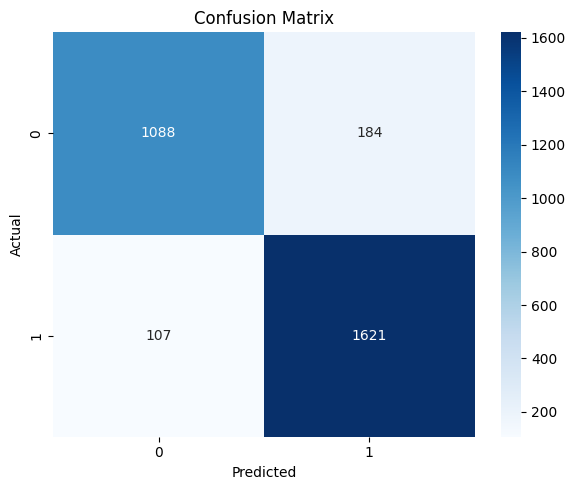

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/confusion_matrix.png",
    dpi=300
)

plt.show()

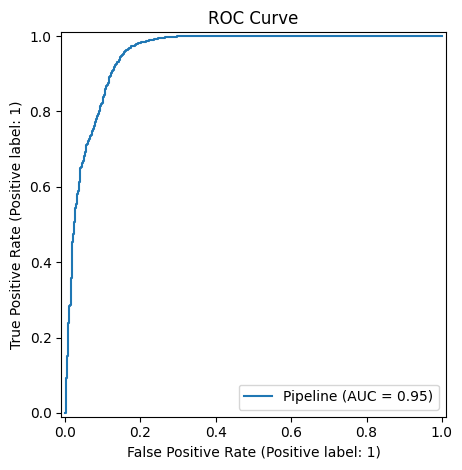

In [22]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/roc_curve.png",
    dpi=300
)

plt.show()

In [23]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]
})

results

,Metric,Score
0,Accuracy,0.903000
1,Precision,0.898061
2,Recall,0.938079
3,F1 Score,0.917634
4,ROC-AUC,0.952398


In [24]:
results.to_csv(
    r"C:\Users\ELCOT\Desktop\Sasirekha-G40 AIML 7\outputs\figures\reports\classification_results.csv",
    index=False
)

In [25]:
joblib.dump(
    best_model,
    "../models/best_logistic_model.pkl"
)

['../models/best_logistic_model.pkl']

Classification Insights
Logistic Regression predicts whether a customer is likely to purchase a product.
Features such as recommendation score, previous purchases, membership level, and browsing behavior influence purchase decisions.
ROC-AUC measures how well the model distinguishes between customers who purchase and those who do not.
This model can support personalized marketing campaigns by identifying high-probability buyers.